<a href="https://colab.research.google.com/github/purgenetik/talpha-privacy/blob/main/TApha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAlpha

Тесты и R&D для приложения
[alpha-decay calculator](https://play.google.com/store/apps/details?id=com.purgenetik.talpha)


## Внешний вид Chart of Nuclide

### Arbitrary value sqrt(dM) on X

Using existing database: /content/talpha_nuclides_1.json
Database versionCode: 1

A = 151
Minimum mass excess = -74653.098 keV

151Eu  Z=63  ME=-74653.098 keV  dE=     0.000 keV  Qα=1963.970 keV
151Gd  Z=64  ME=-74188.920 keV  dE=   464.178 keV  Qα=2652.212 keV
151Tb  Z=65  ME=-71623.541 keV  dE=  3029.557 keV  Qα=3496.154 keV
151Dy  Z=66  ME=-68752.388 keV  dE=  5900.710 keV  Qα=4179.624 keV
151Ho  Z=67  ME=-63622.746 keV  dE= 11030.352 keV  Qα=4695.012 keV
151Er  Z=68  ME=-58266.290 keV  dE= 16386.808 keV  Qα=3504.841 keV
151Tm  Z=69  ME=-50771.613 keV  dE= 23881.485 keV  Qα=2560.572 keV
151Yb  Z=70  ME=-41542.352 keV  dE= 33110.746 keV  Qα=2640.546 keV
151Lu  Z=71  ME=-30300.000 keV  dE= 44353.098 keV  Qα=3249.491 keV


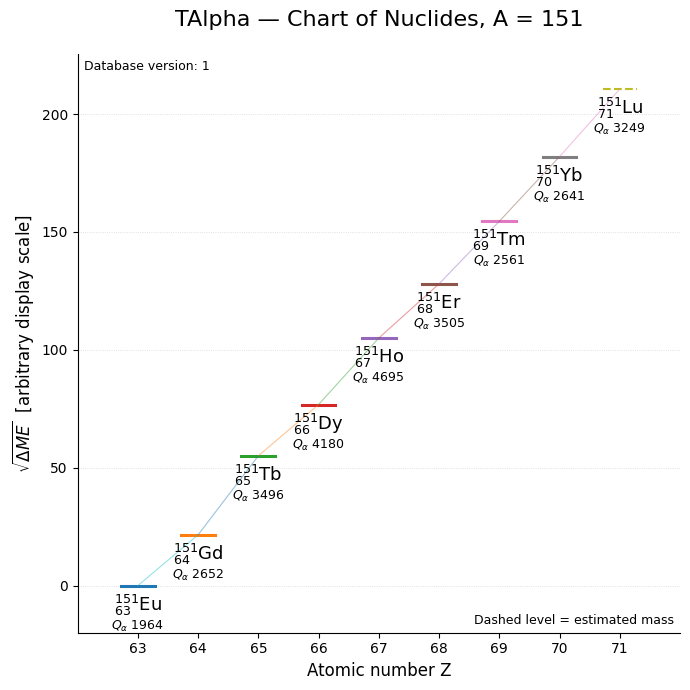

In [ ]:
# ============================================================
# TAlpha Chart of Nuclides — static prototype for Google Colab
# Database: talpha_nuclides_1.json
# Draws A = 151 layer
# ============================================================

import os
import json
import math
import matplotlib.pyplot as plt

from google.colab import files


# ============================================================
# SETTINGS
# ============================================================

DB_FILE = "/content/talpha_nuclides_1.json"
TARGET_A = 151


# ============================================================
# LOAD DATABASE FILE
# ============================================================

if not os.path.exists(DB_FILE):

    print(f"Database not found: {DB_FILE}")
    print("Please select talpha_nuclides_1.json from your computer.")

    uploaded = files.upload()

    # If uploaded under another name, use the uploaded filename
    uploaded_names = list(uploaded.keys())

    if not uploaded_names:
        raise RuntimeError("No file was uploaded.")

    uploaded_name = uploaded_names[0]
    uploaded_path = f"/content/{uploaded_name}"

    # Rename to expected database filename if needed
    if uploaded_path != DB_FILE:
        os.rename(uploaded_path, DB_FILE)

    print(f"Database saved as: {DB_FILE}")

else:
    print(f"Using existing database: {DB_FILE}")


# ============================================================
# READ JSON
# ============================================================

with open(DB_FILE, "r", encoding="utf-8") as f:
    db = json.load(f)

print("Database versionCode:", db["versionCode"])


# ============================================================
# FIND A-LAYER
# ============================================================

layer = None

for item in db["layers"]:
    if item["A"] == TARGET_A:
        layer = item
        break

if layer is None:
    raise ValueError(f"A={TARGET_A} layer not found in database.")


nuclides = layer["nuclides"]

if not nuclides:
    raise ValueError(f"A={TARGET_A} layer contains no nuclides.")


# ============================================================
# PREPARE COORDINATES
# ============================================================

mass_min = min(n["massExcess"] for n in nuclides)

points = []

for n in nuclides:

    relative_energy = n["massExcess"] - mass_min

    # Square-root energy coordinate, similar to original chart
    y = math.sqrt(max(relative_energy, 0.0))

    points.append({
        **n,
        "relativeEnergy": relative_energy,
        "x": n["Z"],
        "y": y
    })


# ============================================================
# PRINT DATA USED FOR PLOT
# ============================================================

print()
print(f"A = {TARGET_A}")
print(f"Minimum mass excess = {mass_min:.3f} keV")
print()

for p in points:
    print(
        f"{TARGET_A}{p['symbol']:>2s}  "
        f"Z={p['Z']:2d}  "
        f"ME={p['massExcess']:10.3f} keV  "
        f"dE={p['relativeEnergy']:10.3f} keV  "
        f"Qα={p['qAlpha']:8.3f} keV"
    )


# ============================================================
# DRAW
# ============================================================

fig, ax = plt.subplots(figsize=(7,7))


# ------------------------------------------------------------
# Nuclear ground-state lines + labels
# ------------------------------------------------------------
NUCLIDE_LABEL_DY = 3.0
QALPHA_LABEL_DY = 14.0
half_width = 0.28

for p in points:

    x = p["x"]
    y = p["y"]

    # Ground-state horizontal line
    if p["estimated"]:
        ax.plot(
            [x - half_width, x + half_width],
            [y, y],
            linewidth=1.5,
            linestyle="--"
        )
    else:
        ax.plot(
            [x - half_width, x + half_width],
            [y, y],
            linewidth=2.2
        )

    # Nuclide label
    label = rf"$^{{{TARGET_A}}}_{{{p['Z']}}}\mathrm{{{p['symbol']}}}$"

    ax.text(
        x,
        y - NUCLIDE_LABEL_DY,
        label,
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold"
    )

    # Q alpha
    if p["qAlpha"] > 0:

        q_text = rf"$Q_\alpha$ {p['qAlpha']:.0f}"

    else:

        q_text = rf"$Q_\alpha$ —"

    ax.text(
        x,
        y - QALPHA_LABEL_DY,
        q_text,
        ha="center",
        va="top",
        fontsize=9
    )


# ============================================================
# CONNECT NUCLEI VISUALLY
# ============================================================

# This is only a visual guide for the prototype.
# It is NOT a decay-path representation.

points_sorted = sorted(points, key=lambda p: p["Z"])

for p1, p2 in zip(points_sorted[:-1], points_sorted[1:]):

    ax.plot(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        linewidth=0.8,
        alpha=0.45
    )


# ============================================================
# AXES
# ============================================================

z_values = [p["Z"] for p in points]
y_values = [p["y"] for p in points]

ax.set_xlim(min(z_values) - 1, max(z_values) + 1)

ax.set_ylim(
    min(y_values) - 20,
    max(y_values) + 15
)

ax.set_xticks(z_values)

ax.set_xlabel(
    "Atomic number Z",
    fontsize=12
)

ax.set_ylabel(
    r"$\sqrt{\Delta ME}$  [arbitrary display scale]",
    fontsize=12
)

ax.set_title(
    f"TAlpha — Chart of Nuclides, A = {TARGET_A}",
    fontsize=16,
    pad=20
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.5
)


# ============================================================
# DATABASE INFO
# ============================================================

ax.text(
    0.01,
    0.99,
    f"Database version: {db['versionCode']}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

ax.text(
    0.99,
    0.01,
    "Dashed level = estimated mass",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)


# ============================================================
# CLEANUP
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Y in keV

Using existing database: /content/talpha_nuclides_1.json
Database versionCode: 1

A = 151
Minimum mass excess = -74653.098 keV

151Eu  Z=63  ME=-74653.098 keV  dE=     0.000 keV  Qα=1963.970 keV
151Gd  Z=64  ME=-74188.920 keV  dE=   464.178 keV  Qα=2652.212 keV
151Tb  Z=65  ME=-71623.541 keV  dE=  3029.557 keV  Qα=3496.154 keV
151Dy  Z=66  ME=-68752.388 keV  dE=  5900.710 keV  Qα=4179.624 keV
151Ho  Z=67  ME=-63622.746 keV  dE= 11030.352 keV  Qα=4695.012 keV
151Er  Z=68  ME=-58266.290 keV  dE= 16386.808 keV  Qα=3504.841 keV
151Tm  Z=69  ME=-50771.613 keV  dE= 23881.485 keV  Qα=2560.572 keV
151Yb  Z=70  ME=-41542.352 keV  dE= 33110.746 keV  Qα=2640.546 keV
151Lu  Z=71  ME=-30300.000 keV  dE= 44353.098 keV  Qα=3249.491 keV


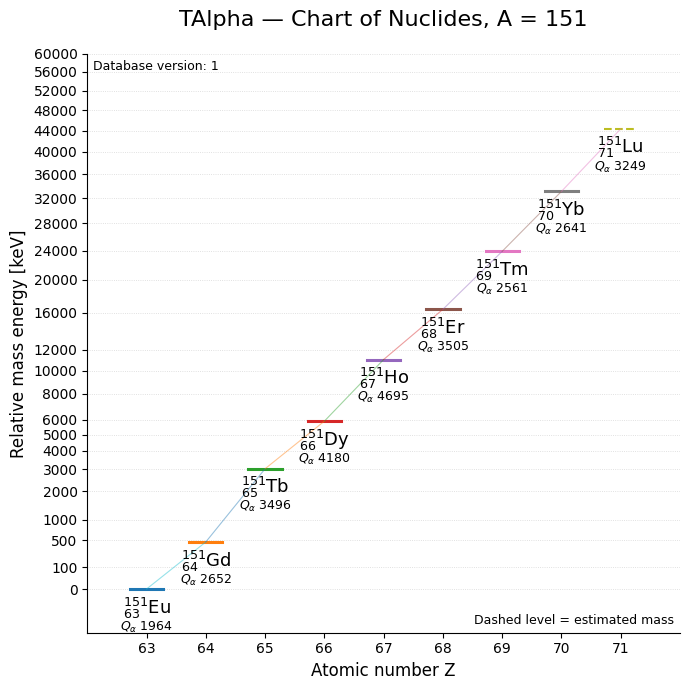

In [ ]:
# ============================================================
# TAlpha Chart of Nuclides — static prototype for Google Colab
# Database: talpha_nuclides_1.json
# Draws A = 151 layer
# ============================================================

import os
import json
import math
import matplotlib.pyplot as plt

from google.colab import files


# ============================================================
# SETTINGS
# ============================================================

DB_FILE = "/content/talpha_nuclides_1.json"
TARGET_A = 151


# ============================================================
# LOAD DATABASE FILE
# ============================================================

if not os.path.exists(DB_FILE):

    print(f"Database not found: {DB_FILE}")
    print("Please select talpha_nuclides_1.json from your computer.")

    uploaded = files.upload()

    # If uploaded under another name, use the uploaded filename
    uploaded_names = list(uploaded.keys())

    if not uploaded_names:
        raise RuntimeError("No file was uploaded.")

    uploaded_name = uploaded_names[0]
    uploaded_path = f"/content/{uploaded_name}"

    # Rename to expected database filename if needed
    if uploaded_path != DB_FILE:
        os.rename(uploaded_path, DB_FILE)

    print(f"Database saved as: {DB_FILE}")

else:
    print(f"Using existing database: {DB_FILE}")


# ============================================================
# READ JSON
# ============================================================

with open(DB_FILE, "r", encoding="utf-8") as f:
    db = json.load(f)

print("Database versionCode:", db["versionCode"])


# ============================================================
# FIND A-LAYER
# ============================================================

layer = None

for item in db["layers"]:
    if item["A"] == TARGET_A:
        layer = item
        break

if layer is None:
    raise ValueError(f"A={TARGET_A} layer not found in database.")


nuclides = layer["nuclides"]

if not nuclides:
    raise ValueError(f"A={TARGET_A} layer contains no nuclides.")


# ============================================================
# PREPARE COORDINATES
# ============================================================

mass_min = min(n["massExcess"] for n in nuclides)

points = []

for n in nuclides:

    relative_energy = n["massExcess"] - mass_min

    # Square-root energy coordinate, similar to original chart
    y = math.sqrt(max(relative_energy, 0.0))

    points.append({
        **n,
        "relativeEnergy": relative_energy,
        "x": n["Z"],
        "y": y
    })


# ============================================================
# PRINT DATA USED FOR PLOT
# ============================================================

print()
print(f"A = {TARGET_A}")
print(f"Minimum mass excess = {mass_min:.3f} keV")
print()

for p in points:
    print(
        f"{TARGET_A}{p['symbol']:>2s}  "
        f"Z={p['Z']:2d}  "
        f"ME={p['massExcess']:10.3f} keV  "
        f"dE={p['relativeEnergy']:10.3f} keV  "
        f"Qα={p['qAlpha']:8.3f} keV"
    )


# ============================================================
# DRAW
# ============================================================

fig, ax = plt.subplots(figsize=(7,7))


# ------------------------------------------------------------
# Nuclear ground-state lines + labels
# ------------------------------------------------------------
NUCLIDE_LABEL_DY = 3.0
QALPHA_LABEL_DY = 14.0
half_width = 0.28

for p in points:

    x = p["x"]
    y = p["y"]

    # Ground-state horizontal line
    if p["estimated"]:
        ax.plot(
            [x - half_width, x + half_width],
            [y, y],
            linewidth=1.5,
            linestyle="--"
        )
    else:
        ax.plot(
            [x - half_width, x + half_width],
            [y, y],
            linewidth=2.2
        )

    # Nuclide label
    label = rf"$^{{{TARGET_A}}}_{{{p['Z']}}}\mathrm{{{p['symbol']}}}$"

    ax.text(
        x,
        y - NUCLIDE_LABEL_DY,
        label,
        ha="center",
        va="top",
        fontsize=13,
        fontweight="bold"
    )

    # Q alpha
    if p["qAlpha"] > 0:

        q_text = rf"$Q_\alpha$ {p['qAlpha']:.0f}"

    else:

        q_text = rf"$Q_\alpha$ —"

    ax.text(
        x,
        y - QALPHA_LABEL_DY,
        q_text,
        ha="center",
        va="top",
        fontsize=9
    )


# ============================================================
# CONNECT NUCLEI VISUALLY
# ============================================================

# This is only a visual guide for the prototype.
# It is NOT a decay-path representation.

points_sorted = sorted(points, key=lambda p: p["Z"])

for p1, p2 in zip(points_sorted[:-1], points_sorted[1:]):

    ax.plot(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        linewidth=0.8,
        alpha=0.45
    )


# ============================================================
# AXES
# ============================================================

z_values = [p["Z"] for p in points]
y_values = [p["y"] for p in points]

ax.set_xlim(min(z_values) - 1, max(z_values) + 1)

ax.set_ylim(
    min(y_values) - 20,
    max(y_values) + 15
)

ax.set_xticks(z_values)

ax.set_xlabel(
    "Atomic number Z",
    fontsize=12
)

# ============================================================
# Y AXIS — REAL ENERGY LABELS IN keV
# ============================================================

energy_ticks = [
    0,
    100,
    500,
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    8000,
    10000,
    12000,
    16000,
    20000,
    24000,
    28000,
    32000,
    36000,
    40000,
    44000,
    48000,
    52000,
    56000,
    60000
]

# Convert physical energy values to plot coordinates
y_tick_positions = [
    math.sqrt(e)
    for e in energy_ticks
]

ax.set_yticks(y_tick_positions)

ax.set_yticklabels([
    str(e)
    for e in energy_ticks
])

ax.set_ylabel(
    "Relative mass energy [keV]",
    fontsize=12
)

ax.set_title(
    f"TAlpha — Chart of Nuclides, A = {TARGET_A}",
    fontsize=16,
    pad=20
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.6,
    alpha=0.5
)


# ============================================================
# DATABASE INFO
# ============================================================

ax.text(
    0.01,
    0.99,
    f"Database version: {db['versionCode']}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

ax.text(
    0.99,
    0.01,
    "Dashed level = estimated mass",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)


# ============================================================
# CLEANUP
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Чарт  альфа-распада на возбужденные уровни


Функция plot_alpha_decay_scheme загружена
Experimental transitions plotted: 3
Saved: alpha_decay_152Gd_visual_test.png


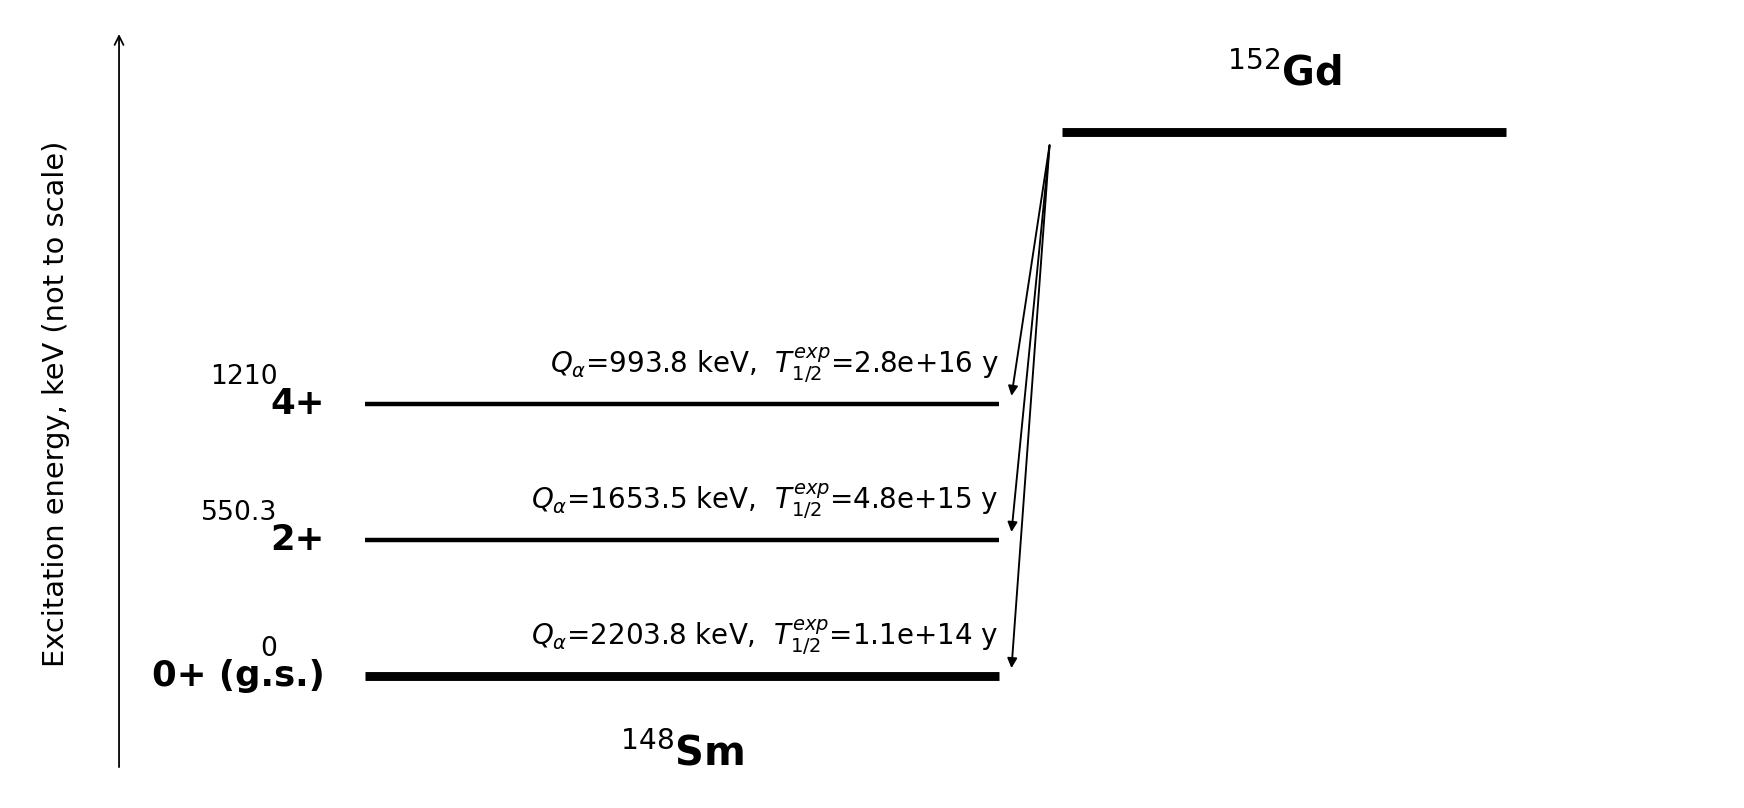

NOTE: excited levels in this test are synthetic layout data.
Eexc=    0.0 keV  Qalpha= 2203.8 keV  Texp=1.100e+14 y  Jpi=0+ (g.s.)
Eexc=  550.3 keV  Qalpha= 1653.5 keV  Texp=4.783e+15 y  Jpi=2+
Eexc= 1210.0 keV  Qalpha=  993.8 keV  Texp=2.750e+16 y  Jpi=4+


In [ ]:
"""Plot an experimental alpha-decay level scheme from TAlpha NDFS v2.2."""

from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt


SECONDS_PER_YEAR = 31_557_600.0


def _number(quantity: Any, unit: str | None = None) -> float | None:
    if not isinstance(quantity, dict):
        return None
    value = quantity.get("value")
    if not isinstance(value, (int, float)) or isinstance(value, bool):
        return None
    if unit is not None and str(quantity.get("unit", "")).lower() != unit.lower():
        return None
    return float(value)


def _spin_label(spin_parity: Any, ground: bool = False) -> str:
    if isinstance(spin_parity, dict):
        label = spin_parity.get("stringRepresentation")
        if label:
            return f"{label} (g.s.)" if ground else str(label)
    return "0+ (g.s.)" if ground else "?"


def _sci(value: float, sig: int = 2) -> str:
    if value == 0:
        return "0"
    exponent = int(math.floor(math.log10(abs(value))))
    mantissa = value / 10**exponent
    text = f"{mantissa:.{max(0, sig - 1)}f}".rstrip("0").rstrip(".")
    return f"{text}e{exponent:+d}"


def _find_nuclide(database: dict, A: int, Z: int) -> dict:
    for layer in database.get("layers", []):
        if layer.get("A") != A:
            continue
        for nuclide in layer.get("nuclides", []):
            if nuclide.get("Z") == Z:
                return nuclide
    raise KeyError(f"Nuclide A={A}, Z={Z} is absent from the database")


def _dataset_id(obj: dict) -> str | None:
    value = obj.get("datasetId")
    if value is None:
        value = (obj.get("dataset") or {}).get("id")
    if value is None:
        value = (obj.get("datasetSummary") or {}).get("id")
    return None if value is None else str(value)


def _prepare_transitions(nuclide: dict, A: int, Z: int) -> tuple[dict, list[dict]]:
    alpha = nuclide.get("alphaDecay") or {}
    decays = alpha.get("decays") or []
    transitions = alpha.get("transitions") or []

    valid_decays = []
    for decay in decays:
        parent = decay.get("parent") or {}
        mode = str(decay.get("decayMode", "")).upper()
        if parent.get("A") == A and parent.get("Z") == Z and mode in {"A", "ALPHA", "Α"}:
            valid_decays.append(decay)
    if not valid_decays:
        raise ValueError(f"No validated alpha-decay record for A={A}, Z={Z}")

    # Prefer the unique ground-state parent dataset.
    ground = []
    for decay in valid_decays:
        parent = decay.get("parent") or {}
        energy = _number(parent.get("levelEnergy"), "keV")
        if energy is not None and abs(energy) <= 1e-9:
            ground.append(decay)
    if len(ground) != 1:
        raise ValueError(f"Expected one ground-state decay dataset; found {len(ground)}")
    decay = ground[0]

    q_gs = _number(decay.get("qValue"), "keV")
    if q_gs is None:
        q_gs = float(nuclide.get("qAlpha", 0)) or None
    if q_gs is None:
        raise ValueError("Ground-state Q-alpha is unavailable")

    t_parent = decay.get("halfLifeYears")
    if not isinstance(t_parent, (int, float)) or t_parent <= 0:
        seconds = _number(decay.get("halfLifeSeconds"), "s")
        t_parent = seconds / SECONDS_PER_YEAR if seconds else None
    if not t_parent:
        raise ValueError("Experimental parent half-life is unavailable")

    branching = _number(decay.get("branchingRatio"))
    if branching is None:
        branching = 1.0
    if branching > 1.0:  # tolerate percent-form input
        branching /= 100.0

    decay_dataset = _dataset_id(decay)
    matched = [t for t in transitions if decay_dataset is None or _dataset_id(t) in {None, decay_dataset}]

    rows = []
    single = len(matched) == 1
    for transition in matched:
        level = transition.get("finalLevel") or {}
        e_exc = _number(level.get("energy"), "keV")
        if e_exc is None or e_exc < 0:
            continue
        intensity = _number(transition.get("intensity"))
        if intensity is not None:
            # ENSDF alpha intensity is expressed in percent. Thus 0.2 means
            # 0.2%, not a dimensionless fraction of 0.2.
            intensity_fraction = intensity / 100.0
        elif single:
            intensity_fraction = 1.0
        else:
            # A branch-specific experimental half-life cannot be determined.
            continue
        probability = branching * intensity_fraction
        if probability <= 0:
            continue
        rows.append({
            "Eexc": e_exc,
            "spin": _spin_label(level.get("spinParity"), ground=abs(e_exc) <= 1e-9),
            "Qalpha": q_gs - e_exc,
            "Texp": float(t_parent) / probability,
            "intensity": intensity,
            "transition": transition,
        })

    if not rows:
        raise ValueError("No transitions contain Eexc, Qalpha and sufficient experimental T1/2 data")
    rows.sort(key=lambda row: row["Eexc"])
    return decay, rows


def plot_alpha_decay_scheme(
    db_file: str | Path,
    A: int,
    Z: int,
    output_file: str | Path | None = None,
    level_gap: float = 1.0,
    show: bool = True,
):
    """Draw a not-to-scale experimental alpha-decay level scheme.

    Vertical level positions are equally spaced; printed Eexc values remain physical.
    Returns ``(fig, ax, plotted_rows)``.
    """
    db_file = Path(db_file)
    database = json.loads(db_file.read_text(encoding="utf-8-sig"))
    nuclide = _find_nuclide(database, A, Z)
    decay, rows = _prepare_transitions(nuclide, A, Z)

    parent_symbol = nuclide.get("symbol", "?")
    daughter = decay.get("daughter") or {}
    daughter_A = daughter.get("A", A - 4)
    daughter_name = daughter.get("name") or f"{daughter_A}?"
    daughter_symbol = "".join(ch for ch in str(daughter_name) if ch.isalpha()).title()
    if not daughter_symbol:
        daughter_symbol = "?"

    n = len(rows)
    y_levels = [i * level_gap for i in range(n)]
    parent_y = n * level_gap + 1.0
    fig_height = max(5.0, 2.0 + 1.05 * n)
    fig, ax = plt.subplots(figsize=(11.0, fig_height), dpi=160)

    # Geometry in data coordinates; y is intentionally an ordinal display coordinate.
    daughter_x1, daughter_x2 = 0.22, 0.62
    # Parent begins only slightly to the right of the daughter levels.
    parent_x1, parent_x2 = 0.66, 0.94

    for row, y in zip(rows, y_levels):
        is_ground = abs(row["Eexc"]) <= 1e-9
        ax.plot(
            [daughter_x1, daughter_x2], [y, y],
            color="black", lw=4.0 if is_ground else 2.0,
            solid_capstyle="butt",
        )
        ax.text(daughter_x1 - 0.025, y, row["spin"], ha="right", va="center",
                fontsize=16, fontweight="bold")
        ax.text(daughter_x1 - 0.055, y + 0.20, f"{row['Eexc']:g}", ha="right",
                va="center", fontsize=12)
        # Transition label sits directly above the daughter level and its
        # right edge is aligned with the right edge of that level.
        ax.text(
            daughter_x2, y + 0.14,
            rf"$Q_\alpha$={row['Qalpha']:.1f} keV,  "
            rf"$T_{{1/2}}^{{exp}}$={_sci(row['Texp'])} y",
            ha="right", va="bottom", fontsize=12.5,
        )

        # One thin decay arrow for every experimentally known transition.
        ax.annotate(
            "",
            xy=(daughter_x2 + 0.008, y + 0.06),
            xytext=(parent_x1 - 0.008, parent_y - 0.10),
            arrowprops=dict(
                arrowstyle="-|>",
                lw=0.85,
                color="black",
                mutation_scale=9,
                shrinkA=0,
                shrinkB=0,
            ),
            zorder=1,
        )

    ax.plot([parent_x1, parent_x2], [parent_y, parent_y], color="black", lw=4.0,
            solid_capstyle="butt")
    ax.text((parent_x1 + parent_x2) / 2, parent_y + 0.27,
            rf"$^{{{A}}}${parent_symbol}", ha="center", va="bottom",
            fontsize=18, fontweight="bold")
    ax.text((daughter_x1 + daughter_x2) / 2, -0.42,
            rf"$^{{{daughter_A}}}${daughter_symbol}", ha="center", va="top",
            fontsize=18, fontweight="bold")

    # Not-to-scale vertical guide.
    ax.annotate("", xy=(0.065, parent_y + 0.75), xytext=(0.065, -0.7),
                arrowprops=dict(arrowstyle="->", lw=0.8, color="black"))
    ax.text(0.025, parent_y / 2, "Excitation energy, keV (not to scale)",
            rotation=90, ha="center", va="center", fontsize=13)

    ax.set_xlim(0, 1.08)
    ax.set_ylim(-0.85, parent_y + 0.85)
    ax.axis("off")
    fig.tight_layout()

    if output_file is None:
        output_file = db_file.with_name(f"alpha_decay_{A}{parent_symbol}.png")
    output_file = Path(output_file)
    fig.savefig(output_file, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Experimental transitions plotted: {len(rows)}")
    print(f"Saved: {output_file}")
    if show:
        plt.show()
    return fig, ax, rows


# Google Colab example:
# fig, ax, rows = plot_alpha_decay_scheme(
#     db_file="talpha_152_152_nuclides.json",
#     A=152,
#     Z=64,
# )

print("Функция plot_alpha_decay_scheme загружена")

"""Visual test with two synthetic excited levels added to real 152Gd data.

The added 550.3 and 1210.0 keV branches are layout fixtures only. They are not
written back to the TAlpha database and must not be interpreted as ENSDF data.
"""

import copy
import json
from pathlib import Path

#from plot_alpha_decay_scheme import plot_alpha_decay_scheme


SOURCE_DB = Path("talpha_152_152_nuclides.json")
DEMO_DB = Path("talpha_152Gd_visual_test.json")


database = json.loads(SOURCE_DB.read_text(encoding="utf-8-sig"))

gd152 = next(
    nuclide
    for layer in database["layers"]
    if layer["A"] == 152
    for nuclide in layer["nuclides"]
    if nuclide["Z"] == 64
)

ground_transition = gd152["alphaDecay"]["transitions"][0]


def synthetic_transition(record_id, energy_kev, spin, intensity_percent):
    transition = copy.deepcopy(ground_transition)
    transition["id"] = record_id
    transition["finalLevel"]["id"] = record_id + 100000
    transition["finalLevel"]["energy"] = {
        "value": energy_kev,
        "unit": "keV",
        "uncertainty": {"type": "none"},
    }
    transition["finalLevel"]["spinParity"] = {
        "stringRepresentation": spin,
        "values": [],
    }
    transition["intensity"] = {
        "value": intensity_percent,
        "uncertainty": {"type": "none"},
    }
    return transition


gd152["alphaDecay"]["transitions"].extend([
    synthetic_transition(900001, 550.3, "2+", 2.3),
    synthetic_transition(900002, 1210.0, "4+", 0.4),
])

DEMO_DB.write_text(
    json.dumps(database, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

fig, ax, rows = plot_alpha_decay_scheme(
    db_file=DEMO_DB,
    A=152,
    Z=64,
    output_file="alpha_decay_152Gd_visual_test.png",
)

print("NOTE: excited levels in this test are synthetic layout data.")
for row in rows:
    print(
        f"Eexc={row['Eexc']:7.1f} keV  "
        f"Qalpha={row['Qalpha']:7.1f} keV  "
        f"Texp={row['Texp']:.3e} y  "
        f"Jpi={row['spin']}"
    )



# Read of API NNDC

## Извлечение ENSDF альфа-данных для заданного изотопа

In [ ]:
# ============================================================
# TAlpha — ENSDF alpha-decay data downloader
#
# Saves:
#     ENSDF_alpha_<A><Symbol>.json
#
# Example:
#     alpha_data = get_alpha_data_from_ensdf(152, 64)
# ============================================================

import json
from pathlib import Path

import requests


BASE_URL = "https://www.nndc.bnl.gov/ensdf-api"


# ============================================================
# PERIODIC TABLE
# ============================================================

ELEMENTS = [
    None,
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
    "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og"
]


# ============================================================
# API HELPERS
# ============================================================

def _api_get(session, endpoint, params=None):
    """
    Send a GET request to the ENSDF API and return decoded JSON.
    """

    url = BASE_URL + endpoint

    response = session.get(
        url,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    return response.json()


def _unpack_results(data):
    """
    Extract the record array from a paginated ENSDF response.
    """

    if isinstance(data, list):
        return data

    if not isinstance(data, dict):
        return []

    for key in (
        "results",
        "items",
        "data",
        "records"
    ):
        value = data.get(key)

        if isinstance(value, list):
            return value

    return []


def _is_alpha_dataset(dataset):
    """
    Check whether an ENSDF dataset describes alpha decay.
    """

    document_type = str(
        dataset.get("documentType", "")
    ).strip().lower()

    dataset_name = str(
        dataset.get("datasetName", "")
    ).strip().upper()

    return (
        document_type == "alphadecay"
        or " A DECAY" in dataset_name
        or dataset_name.endswith("A DECAY")
    )


def _is_alpha_decay(record):
    """
    Check the decay mode in an ENSDF decay record.
    """

    mode = str(
        record.get("decayMode", "")
    ).strip().upper()

    return mode in {
        "A",
        "ALPHA",
        "Α"
    }


def _is_requested_parent(record, A, Z):
    """
    Check that the requested nucleus is the parent,
    not merely the daughter.
    """

    parent = record.get("parent") or {}

    parent_A = parent.get("a")
    parent_Z = parent.get("z")

    return (
        parent_A == A
        and parent_Z == Z
    )


def _dataset_id(record):
    """
    Obtain dataset ID from an ENSDF record.
    """

    dataset_summary = (
        record.get("datasetSummary")
        or {}
    )

    return (
        record.get("datasetId")
        or dataset_summary.get("id")
    )


# ============================================================
# MAIN FUNCTION
# ============================================================

def get_alpha_data_from_ensdf(A, Z):
    """
    Download complete ENSDF alpha-decay information for parent
    nucleus (A, Z).

    ENSDF stores an alpha-decay dataset under the daughter nucleus:

        (A, Z) -> (A - 4, Z - 2) + alpha

    The function saves:

        ENSDF_alpha_<A><Symbol>.json

    The output follows the complete archival format defined
    in TAlpha NDFS specification v2.2.

    Parameters
    ----------
    A : int
        Parent mass number.

    Z : int
        Parent atomic number.

    Returns
    -------
    dict
        Complete downloaded ENSDF alpha-decay archive.
    """

    # --------------------------------------------------------
    # Validate input
    # --------------------------------------------------------

    if not isinstance(A, int) or A <= 0:
        raise ValueError(
            "A must be a positive integer"
        )

    if (
        not isinstance(Z, int)
        or not 1 <= Z < len(ELEMENTS)
    ):
        raise ValueError(
            f"Unknown atomic number Z={Z}"
        )

    parent_symbol = ELEMENTS[Z]

    daughter_A = A - 4
    daughter_Z = Z - 2

    if daughter_A <= 0 or daughter_Z <= 0:
        raise ValueError(
            f"{A}-{parent_symbol} cannot undergo "
            "ordinary alpha decay"
        )

    daughter_symbol = ELEMENTS[daughter_Z]

    parent_name = (
        f"{A}{parent_symbol.upper()}"
    )

    daughter_name = (
        f"{daughter_A}{daughter_symbol.upper()}"
    )

    # --------------------------------------------------------
    # Prepare output collections
    # --------------------------------------------------------

    alpha_decays = []
    datasets = []
    alpha_radiations = []

    seen_decay_ids = set()
    seen_dataset_ids = set()
    seen_alpha_ids = set()

    # --------------------------------------------------------
    # ENSDF requests
    # --------------------------------------------------------

    with requests.Session() as session:

        session.headers.update({
            "Accept": "application/json",
            "User-Agent": "TAlpha-ENSDF-client/2.2"
        })

        # ENSDF alpha-decay datasets are stored under
        # the daughter nucleus.
        try:
            datasets_response = _api_get(
                session,
                f"/nuclides/{daughter_name}/datasets",
                params={
                    "limit": 500
                }
            )

            daughter_datasets = _unpack_results(
                datasets_response
            )

        except requests.HTTPError as error:

            if (
                error.response is not None
                and error.response.status_code == 404
            ):
                # Daughter nucleus ets not present in ENSDF.
                # Treat this as auccino Nus empty result, not a program error.
                daughter_datasets = []

            else:
                raise

        alpha_dataset_summaries = [
            dataset
            for dataset in daughter_datasets
            if _is_alpha_dataset(dataset)
        ]

        # ----------------------------------------------------
        # Inspect every alpha-decay dataset of the daughter
        # ----------------------------------------------------

        for summary in alpha_dataset_summaries:

            dataset_id = summary.get("id")

            if dataset_id is None:
                continue

            # Complete dataset object
            dataset = _api_get(
                session,
                f"/datasets/{dataset_id}"
            )

            # Decay edges belonging to this dataset
            decays_response = _api_get(
                session,
                f"/datasets/{dataset_id}/decays",
                params={
                    "include-comments": "true",
                    "include-evaluator-input": "true",
                    "limit": 500
                }
            )

            dataset_decays = _unpack_results(
                decays_response
            )

            matching_decays = [
                record
                for record in dataset_decays
                if (
                    _is_alpha_decay(record)
                    and _is_requested_parent(
                        record,
                        A,
                        Z
                    )
                )
            ]

            # The daughter may have alpha-decay datasets
            # belonging to several different parents.
            if not matching_decays:
                continue

            # Alpha-radiation records from the same dataset
            alphas_response = _api_get(
                session,
                f"/datasets/{dataset_id}/alphas",
                params={
                    "include-comments": "true",
                    "include-evaluator-input": "true",
                    "limit": 500
                }
            )

            dataset_alphas = _unpack_results(
                alphas_response
            )

            # ------------------------------------------------
            # Save complete dataset
            # ------------------------------------------------

            if dataset_id not in seen_dataset_ids:
                seen_dataset_ids.add(dataset_id)
                datasets.append(dataset)

            # ------------------------------------------------
            # Save matching decay records
            # ------------------------------------------------

            for decay in matching_decays:

                decay_id = decay.get("id")

                # Fallback identity if the API record has no ID
                decay_key = (
                    decay_id
                    if decay_id is not None
                    else json.dumps(
                        decay,
                        sort_keys=True,
                        ensure_ascii=False
                    )
                )

                if decay_key not in seen_decay_ids:
                    seen_decay_ids.add(decay_key)
                    alpha_decays.append(decay)

            # ------------------------------------------------
            # Save alpha-radiation records
            # ------------------------------------------------

            for alpha in dataset_alphas:

                # Accept the record only if it belongs
                # to the current matched dataset.
                alpha_dataset_id = _dataset_id(alpha)

                if (
                    alpha_dataset_id is not None
                    and str(alpha_dataset_id) != str(dataset_id)
                ):
                    continue

                alpha_id = alpha.get("id")

                alpha_key = (
                    alpha_id
                    if alpha_id is not None
                    else json.dumps(
                        alpha,
                        sort_keys=True,
                        ensure_ascii=False
                    )
                )

                if alpha_key not in seen_alpha_ids:
                    seen_alpha_ids.add(alpha_key)
                    alpha_radiations.append(alpha)

    # --------------------------------------------------------
    # Complete archival JSON defined by TAlpha NDFS v2.2
    # --------------------------------------------------------

    result = {
        "source": {
            "database": "ENSDF",
            "api": BASE_URL
        },
        "parent": {
            "A": A,
            "Z": Z,
            "symbol": parent_symbol,
            "name": f"{A}{parent_symbol}"
        },
        "daughter": {
            "A": daughter_A,
            "Z": daughter_Z,
            "symbol": daughter_symbol,
            "name": f"{daughter_A}{daughter_symbol}"
        },
        "alphaDecays": alpha_decays,
        "datasets": datasets,
        "alphaRadiations": alpha_radiations
    }

    # --------------------------------------------------------
    # Do not overwrite a valid existing file with empty data
    # --------------------------------------------------------

    output_path = Path(
        f"ENSDF_alpha_{A}{parent_symbol}.json"
    )

    if not alpha_decays:

        # Save a valid empty ENSDF archive.
        # Its presence marks this nuclide as already checked.
        output_path.write_text(
            json.dumps(
                result,
                ensure_ascii=False,
                indent=2
            ),
            encoding="utf-8"
        )

        print(
            f"Nuclide          : {A}-{parent_symbol} "
            f"(Z={Z})"
        )
        print("Alpha decays     : 0")
        print("ENSDF datasets   : 0")
        print("Alpha radiations : 0")
        print(
            f"Saved empty file : {output_path}"
        )

        return result

    if not alpha_decays: ##########

        print(
            f"Nuclide          : {A}-{parent_symbol} "
            f"(Z={Z})"
        )
        print("Alpha decays     : 0")
        print("ENSDF datasets   : 0")
        print("Alpha radiations : 0")

        if output_path.exists():
            print(
                "File not overwritten:",
                output_path
            )
        else:
            print(
                "File not created because no validated "
                "alpha-decay data were found."
            )

        return result

    # --------------------------------------------------------
    # Save UTF-8 JSON
    # --------------------------------------------------------

    output_path.write_text(
        json.dumps(
            result,
            ensure_ascii=False,
            indent=2
        ),
        encoding="utf-8"
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    print(
        f"Nuclide          : {A}-{parent_symbol} "
        f"(Z={Z})"
    )
    print(
        f"Alpha decays     : {len(alpha_decays)}"
    )
    print(
        f"ENSDF datasets   : {len(datasets)}"
    )
    print(
        f"Alpha radiations : {len(alpha_radiations)}"
    )
    print(
        f"Saved            : {output_path}"
    )

    return result
print("Функция get_alpha_data_from_ensdf(A,Z) загружена")


Функция get_alpha_data_from_ensdf(A,Z) загружена


## Постройка TAlpha DB

In [ ]:
"""Build a TAlpha NDFS v2.2 database from the published v1 database.

Designed for Google Colab. Define/import ``get_alpha_data_from_ensdf(A, Z)``
before calling ``build_talpha_db``.
"""

from __future__ import annotations

import copy
import json
import math
import shutil
import zipfile
from pathlib import Path
from typing import Any, Callable


MANIFEST_FILE_ID = "1yPQ9LPeO3e3e-t006o3UcW9DOmfKJdK6"
SECONDS_PER_YEAR = 31_557_600.0

ELEMENTS = [
    None,
    "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne",
    "Na", "Mg", "Al", "Si", "P", "S", "Cl", "Ar", "K", "Ca",
    "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn",
    "Ga", "Ge", "As", "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr",
    "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd",
    "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb",
    "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg",
    "Tl", "Pb", "Bi", "Po", "At", "Rn", "Fr", "Ra", "Ac", "Th",
    "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm",
    "Md", "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds",
    "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og",
]


def _download_google_drive(file_id: str, output: Path) -> Path:
    try:
        import gdown
    except ImportError as exc:
        raise RuntimeError(
            "gdown is required in Colab. Run: !pip install -q gdown"
        ) from exc

    output.parent.mkdir(parents=True, exist_ok=True)
    result = gdown.download(id=file_id, output=str(output), quiet=False)
    if result is None or not output.is_file() or output.stat().st_size == 0:
        raise RuntimeError(f"Google Drive download failed for file ID {file_id}")
    return output


def _load_manifest(work_dir: Path, manifest_file_id: str) -> dict[str, Any]:
    path = work_dir / "talpha_manifest.json"
    _download_google_drive(manifest_file_id, path)
    manifest = json.loads(path.read_text(encoding="utf-8-sig"))
    for key in ("latestVersion", "fileName", "fileID"):
        if key not in manifest:
            raise ValueError(f"Manifest has no required field: {key}")
    return manifest


def _load_v1_database(zip_path: Path) -> dict[str, Any]:
    with zipfile.ZipFile(zip_path, "r") as archive:
        json_names = [
            name for name in archive.namelist()
            if not name.endswith("/") and name.lower().endswith(".json")
        ]
        preferred = [name for name in json_names if "talpha_nuclides" in name.lower()]
        candidates = preferred or json_names
        if len(candidates) != 1:
            raise ValueError(
                "The database ZIP must contain exactly one identifiable JSON file; "
                f"found: {candidates}"
            )
        with archive.open(candidates[0]) as stream:
            database = json.loads(stream.read().decode("utf-8-sig"))

    if not isinstance(database.get("versionCode"), int):
        raise ValueError("Invalid v1 database: versionCode must be an integer")
    if not isinstance(database.get("layers"), list):
        raise ValueError("Invalid v1 database: layers must be an array")
    return database


def _two_significant_figures(value: float) -> float:
    if value == 0:
        return 0.0
    digits = 1 - int(math.floor(math.log10(abs(value))))
    return round(value, digits)


def _quantity_value(quantity: Any, required_unit: str | None = None) -> float | None:
    if not isinstance(quantity, dict):
        return None
    value = quantity.get("value")
    if not isinstance(value, (int, float)) or isinstance(value, bool):
        return None
    unit = str(quantity.get("unit", "")).strip().lower()
    if required_unit is not None and unit != required_unit.lower():
        return None
    return float(value)


def _is_ground_state(parent: dict[str, Any]) -> bool:
    energy = parent.get("levelEnergy")
    value = _quantity_value(energy, "keV")
    return value is not None and abs(value) <= 1e-9


def _normalise_decay(record: dict[str, Any]) -> dict[str, Any]:
    parent = record.get("parent") or {}
    daughter = record.get("daughter") or {}
    summary = record.get("datasetSummary") or {}
    half_life_seconds = parent.get("halfLifeSeconds") or record.get("halfLifeSeconds")
    seconds = _quantity_value(half_life_seconds, "s")
    years = (
        _two_significant_figures(seconds / SECONDS_PER_YEAR)
        if seconds is not None and seconds > 0 else None
    )
    normalisations = parent.get("normalizations") or record.get("normalizations") or {}

    result = {
        "decayId": record.get("id"),
        "decayMode": record.get("decayMode"),
        "parent": {
            "nuclideId": parent.get("nuclideId"),
            "name": parent.get("name"),
            "A": parent.get("a"),
            "Z": parent.get("z"),
            "levelEnergy": parent.get("levelEnergy"),
            "spinParity": parent.get("spinParity"),
        },
        "daughter": {
            "nuclideId": daughter.get("nuclideId"),
            "name": daughter.get("name"),
            "A": daughter.get("a"),
            "Z": daughter.get("z"),
        },
        "halfLife": parent.get("halfLife") or record.get("halfLife"),
        "halfLifeSeconds": half_life_seconds,
        "halfLifeYears": years,
        "qValue": parent.get("qValue") or record.get("qValue"),
        "branchingRatio": normalisations.get("branchingRatio"),
        "normalizations": normalisations or None,
        "dataset": {
            "id": summary.get("id") or record.get("datasetId"),
            "database": summary.get("database"),
            "documentType": summary.get("documentType"),
            "name": summary.get("datasetName"),
            "cutoffDate": summary.get("cutoffDate"),
        },
        "comments": record.get("comments"),
        "raw": record,
    }
    return result

def _validated_parent_decays(
    archive: dict[str, Any],
    A: int,
    Z: int
) -> list[dict[str, Any]]:

    # Raw ENSDF archival format
    records = archive.get("alphaDecays")

    # Normalized TAlpha v2.2 format
    if not isinstance(records, list):
        alpha_decay = archive.get("alphaDecay") or {}
        records = alpha_decay.get("decays")

    if not isinstance(records, list):
        return []

    selected = []

    for record in records:

        if not isinstance(record, dict):
            continue

        mode = str(
            record.get("decayMode", "")
        ).strip().upper()

        parent = record.get("parent") or {}
        daughter = record.get("daughter") or {}

        parent_A = (
            parent.get("A")
            if parent.get("A") is not None
            else parent.get("a")
        )

        parent_Z = (
            parent.get("Z")
            if parent.get("Z") is not None
            else parent.get("z")
        )

        daughter_A = (
            daughter.get("A")
            if daughter.get("A") is not None
            else daughter.get("a")
        )

        daughter_Z = (
            daughter.get("Z")
            if daughter.get("Z") is not None
            else daughter.get("z")
        )

        if mode not in {"A", "ALPHA", "Α"}:
            continue

        if parent_A != A or parent_Z != Z:
            continue

        if (
            daughter_A != A - 4
            or daughter_Z != Z - 2
        ):
            continue

        selected.append(record)

    return selected

def _extract_qalpha(decays: list[dict[str, Any]]) -> float | None:
    values = []
    for record in decays:
        parent = record.get("parent") or {}
        quantity = parent.get("qValue") or record.get("qValue")
        value = _quantity_value(quantity, "keV")
        if value is not None and value > 0:
            values.append(value)
    unique = sorted({round(value, 12) for value in values})
    return unique[0] if len(unique) == 1 else None

def _extract_ground_state_half_life(
    decays: list[dict[str, Any]]
) -> float | None:

    values = []

    for record in decays:

        parent = record.get("parent") or {}

        if not _is_ground_state(parent):
            continue

        years = None

        # ----------------------------------------------------
        # 1. Already calculated value in normalized v2.2 data
        # ----------------------------------------------------

        value_years = record.get("halfLifeYears")

        if (
            isinstance(value_years, (int, float))
            and not isinstance(value_years, bool)
            and value_years > 0
        ):
            years = float(value_years)

        # ----------------------------------------------------
        # 2. halfLifeSeconds at decay-record level
        # ----------------------------------------------------

        if years is None:

            half_life_seconds = record.get(
                "halfLifeSeconds"
            )

            seconds = _quantity_value(
                half_life_seconds,
                "s"
            )

            if seconds is not None and seconds > 0:
                years = seconds / SECONDS_PER_YEAR

        # ----------------------------------------------------
        # 3. Raw ENSDF: halfLifeSeconds inside parent
        # ----------------------------------------------------

        if years is None:

            half_life_seconds = parent.get(
                "halfLifeSeconds"
            )

            seconds = _quantity_value(
                half_life_seconds,
                "s"
            )

            if seconds is not None and seconds > 0:
                years = seconds / SECONDS_PER_YEAR

        # ----------------------------------------------------
        # 4. Direct half-life value expressed in years
        # ----------------------------------------------------

        if years is None:

            half_life = (
                record.get("halfLife")
                or parent.get("halfLife")
            )

            value = _quantity_value(
                half_life,
                "y"
            )

            if value is not None and value > 0:
                years = value

        if years is not None:
            values.append(
                _two_significant_figures(years)
            )

    unique_values = sorted(set(values))

    if len(unique_values) == 1:
        return unique_values[0]

    return None

def _dataset_ids(decays: list[dict[str, Any]]) -> set[str]:
    ids = set()
    for record in decays:
        summary = record.get("datasetSummary") or {}
        value = record.get("datasetId") or summary.get("id")
        if value is not None:
            ids.add(str(value))
    return ids


def _filter_transitions(archive: dict[str, Any], dataset_ids: set[str]) -> list[dict[str, Any]]:
    records = archive.get("alphaRadiations")
    if not isinstance(records, list):
        return []
    selected = []
    for record in records:
        if not isinstance(record, dict):
            continue
        summary = record.get("datasetSummary") or {}
        value = record.get("datasetId") or summary.get("id")
        # Some dataset-scoped ENSDF alpha responses omit datasetId. The downloader
        # has already restricted those records to matched datasets, so retain them.
        if value is None or str(value) in dataset_ids:
            selected.append(record)
    return selected


def _archive_path(ensdf_dir: Path, A: int, Z: int) -> Path:
    if not 1 <= Z < len(ELEMENTS):
        raise ValueError(f"Unknown atomic number Z={Z}")
    # File name is based on the PARENT. get_alpha_data_from_ensdf internally
    # searches the daughter (A-4, Z-2), but saves ENSDF_alpha_<parent>.json.
    return ensdf_dir / f"ENSDF_alpha_{A}{ELEMENTS[Z]}.json"


def _load_or_create_archive(
    A: int,
    Z: int,
    ensdf_dir: Path,
    downloader: Callable[[int, int], dict[str, Any]],
) -> tuple[dict[str, Any], str]:
    path = _archive_path(ensdf_dir, A, Z)
    if path.is_file():
        return json.loads(path.read_text(encoding="utf-8-sig")), "cached"

    ensdf_dir.mkdir(parents=True, exist_ok=True)
    returned = downloader(A, Z)

    # Existing downloader versions write into the current working directory.
    created_here = Path(path.name)
    if path.is_file():
        archive = json.loads(path.read_text(encoding="utf-8-sig"))
    elif created_here.is_file():
        shutil.move(str(created_here), str(path))
        archive = json.loads(path.read_text(encoding="utf-8-sig"))
    elif isinstance(returned, dict):
        archive = returned
        path.write_text(json.dumps(archive, ensure_ascii=False, indent=2), encoding="utf-8")
    else:
        raise RuntimeError("Downloader returned no JSON and created no archive file")
    return archive, "downloaded"


def build_talpha_db(
    Amin: int | None = None,
    Amax: int | None = None,
    ensdf_data: str | Path = "ensdf_data",
    output_dir: str | Path = ".",
    manifest_file_id: str = MANIFEST_FILE_ID,
    output_version: int | None = None,
    create_zip: bool = True,
    continue_on_ensdf_error: bool = True,
    downloader: Callable[[int, int], dict[str, Any]] | None = None,
) -> dict[str, Any]:
    """Build TAlpha NDFS v2.2 by enriching the published v1 database.

    All v1 layers are retained. Only layers inside inclusive ``Amin..Amax`` are
    enriched; omitted bounds mean the minimum/maximum A present in the database.
    ``massExcess`` and ``estimated`` are preserved from v1. A validated ENSDF
    parent qValue replaces qAlpha, and ground-state alpha data add T_hl_exp and
    alphaDecay.
    """

    work_dir = Path(output_dir)
    ensdf_dir = Path(ensdf_data)
    work_dir.mkdir(parents=True, exist_ok=True)
    ensdf_dir.mkdir(parents=True, exist_ok=True)

    if downloader is None:
        downloader = globals().get("get_alpha_data_from_ensdf")
    if not callable(downloader):
        raise RuntimeError(
            "Define/import get_alpha_data_from_ensdf(A, Z) before build_talpha_db(), "
            "or pass it as downloader=."
        )

    manifest = _load_manifest(work_dir, manifest_file_id)
    source_zip = work_dir / str(manifest["fileName"])
    _download_google_drive(str(manifest["fileID"]), source_zip)
    source_db = _load_v1_database(source_zip)

    available_A = [layer.get("A") for layer in source_db["layers"] if isinstance(layer.get("A"), int)]
    if not available_A:
        raise ValueError("The source database contains no valid mass layers")
    selected_min = min(available_A) if Amin is None else Amin
    selected_max = max(available_A) if Amax is None else Amax
    if selected_min > selected_max:
        raise ValueError("Amin must not exceed Amax")

    version = output_version if output_version is not None else int(manifest["latestVersion"]) + 1
    output_db = {
        "versionCode": version,
        "formatVersion": "2.2",
        "layers": copy.deepcopy(source_db["layers"]),
    }
    stats = {
        "layersSelected": 0,
        "nuclidesProcessed": 0,
        "archivesCached": 0,
        "archivesDownloaded": 0,
        "alphaDecayAdded": 0,
        "qAlphaUpdated": 0,
        "noAlphaData": 0,
        "errors": [],
    }

    for layer in output_db["layers"]:
        A = layer.get("A")
        if not isinstance(A, int) or not selected_min <= A <= selected_max:
            continue
        stats["layersSelected"] += 1

        nuclides = layer.get("nuclides")
        if not isinstance(nuclides, list):
            stats["errors"].append(f"Layer A={A}: nuclides is not an array")
            continue

        for nuclide in nuclides:
            Z = nuclide.get("Z")
            if not isinstance(Z, int) or not 1 <= Z < len(ELEMENTS):
                stats["errors"].append(f"Layer A={A}: invalid Z={Z}")
                continue
            stats["nuclidesProcessed"] += 1

            # Preserve and validate all mandatory v1 fields.
            required = ("Z", "symbol", "massExcess", "qAlpha", "estimated")
            missing = [field for field in required if field not in nuclide]
            if missing:
                stats["errors"].append(f"A={A}, Z={Z}: missing v1 fields {missing}")
                continue

            try:
                archive, origin = _load_or_create_archive(A, Z, ensdf_dir, downloader)
                stats[f"archives{origin.capitalize()}"] += 1
                decays = _validated_parent_decays(archive, A, Z)
                if not decays:
                    stats["noAlphaData"] += 1
                    continue

                q_alpha = _extract_qalpha(decays)
                if q_alpha is not None:
                    if nuclide.get("qAlpha") != q_alpha:
                        stats["qAlphaUpdated"] += 1
                    nuclide["qAlpha"] = q_alpha

                normalised = [_normalise_decay(record) for record in decays]
                transitions = _filter_transitions(archive, _dataset_ids(decays))
                nuclide["alphaDecay"] = {
                    "decays": normalised,
                    "transitions": transitions,
                }
                half_life = _extract_ground_state_half_life(decays)
                if half_life is not None:
                    nuclide["T_hl_exp"] = half_life
                else:
                    nuclide.pop("T_hl_exp", None)
                stats["alphaDecayAdded"] += 1

            except Exception as exc:
                message = f"A={A}, Z={Z} ({nuclide.get('symbol')}): {type(exc).__name__}: {exc}"
                stats["errors"].append(message)
                if not continue_on_ensdf_error:
                    raise
    if Amin is not None or Amax is not None:
        output_stem = (
            f"talpha_{selected_min}_{selected_max}_nuclides"
        )
    else:
        output_stem = (
            f"talpha_nuclides_{version}"
        )
    json_path = work_dir / f"{output_stem}.json"
    json_path.write_text(
        json.dumps(output_db, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    zip_path = None
    if create_zip:
        zip_path = work_dir / f"{output_stem}.zip"
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
            archive.write(json_path, arcname=json_path.name)

    print(f"Source DB version : {source_db['versionCode']}")
    print(f"Output DB version : {version}")
    print(f"A range           : {selected_min}..{selected_max}")
    print(f"Layers processed  : {stats['layersSelected']}")
    print(f"Nuclides processed: {stats['nuclidesProcessed']}")
    print(f"Alpha data added  : {stats['alphaDecayAdded']}")
    print(f"qAlpha updated    : {stats['qAlphaUpdated']}")
    print(f"No alpha data     : {stats['noAlphaData']}")
    print(f"Errors            : {len(stats['errors'])}")
    print(f"Saved JSON        : {json_path}")
    if zip_path is not None:
        print(f"Saved ZIP         : {zip_path}")
    if stats["errors"]:
        print("\nFirst errors:")
        for message in stats["errors"][:20]:
            print(" -", message)

    return {
        "database": output_db,
        "manifest": manifest,
        "statistics": stats,
        "jsonPath": str(json_path),
        "zipPath": str(zip_path) if zip_path is not None else None,
    }

dir_out = "/content"
ensdf_data = f"{dir_out}/ensdf_data"

print("Функция build_talpha_db() загружена")
# Google Colab examples:
# result = build_talpha_db(ensdf_data="/content/ensdf_data")
# result = build_talpha_db(Amin=151, Amax=160, ensdf_data="/content/ensdf_data")


Функция build_talpha_db() загружена


## Скачивание оригинальной ENSDF базы

Код ниже скачивает оригинальную базу ENDSF, чтобы использовать ее для создания TAlpha базы данных.

Если вы хотите создать актуализировать уже имеющуюся ENSDF базу (скачать по новой данные об альфа-распадных ядрах) тогда пропустите данный шаг

In [ ]:
import os
import shutil
import gdown

# for test, in real work defined above
#dir_out = "/content/data"
#ensdf_data = f"{dir_out}/ensdf_data"
os.makedirs(dir_out, exist_ok=True)

file_url = (
    "https://drive.google.com/file/d/"
    "1QtGRJxAJeBofbynJD-Los21ggvTMG-gC/view?usp=drive_link"
)

archive_path = "/content/ensdf_data.zip"

if not os.path.isdir(dir_out):
#    raise FileNotFoundError(f"Directory not found: {ensdf_data}")
  # Создаём выходную директорию
  os.makedirs(dir_out, exist_ok=True)

if not os.path.isdir(dir_out):
    raise FileNotFoundError(f"Directory is not accessible: {ensdf_data}")

# Скачиваем ZIP с Google Drive
gdown.download(
    url=file_url,
    output=archive_path,
    quiet=False,
    fuzzy=True
)

if not os.path.isfile(archive_path):
    raise FileNotFoundError("The archive was not downloaded")

# Распаковываем архив
shutil.unpack_archive(
    filename=archive_path,
    extract_dir=dir_out,
    format="zip"
)

print(f"\nDatabase extracted to: {dir_out}")

Downloading...
From: https://drive.google.com/uc?id=1QtGRJxAJeBofbynJD-Los21ggvTMG-gC
To: /content/ensdf_data.zip
100%|██████████| 1.03M/1.03M [00:00<00:00, 110MB/s]


Database extracted to: /content/data


### Запуск создания полной базы

In [ ]:
#result = build_talpha_db(ensdf_data="/content/ensdf_data")
result = build_talpha_db(151,151,ensdf_data="/content/ensdf_data")

Downloading...
From: https://drive.google.com/uc?id=1yPQ9LPeO3e3e-t006o3UcW9DOmfKJdK6
To: /content/talpha_manifest.json
100%|██████████| 118/118 [00:00<00:00, 244kB/s]
Downloading...
From: https://drive.google.com/uc?id=1OvpIWB4cUMoewqubZbsiguhdcgxKIabz
To: /content/talpha_nuclides_6.zip
100%|██████████| 628k/628k [00:00<00:00, 96.3MB/s]


Source DB version : 6
Output DB version : 7
A range           : 151..151
Layers processed  : 1
Nuclides processed: 9
Alpha data added  : 5
qAlpha updated    : 0
No alpha data     : 4
Errors            : 0
Saved JSON        : talpha_151_151_nuclides.json
Saved ZIP         : talpha_151_151_nuclides.zip


## Сохранение оригинальной ENSDF базы


In [ ]:
import os
import shutil
from google.colab import files

data = "/content/ensdf_data"

if not os.path.isdir(data):
    raise FileNotFoundError(f"Directory not found: {data}")

archive_name = os.path.basename(os.path.normpath(data))
archive_path = shutil.make_archive(
    base_name=f"/content/{archive_name}",
    format="zip",
    root_dir=os.path.dirname(data),
    base_dir=os.path.basename(data)
)

print(f"Archive created: {archive_path}")
files.download(archive_path)

Archive created: /content/ensdf_data.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>